# Hidden Markov Models (HMM)
- model sequenves where the underlying states are hidden but can produce observable outputs - fitting well with movement analysis


Steps :
- Align trials using DTW - sinceHMM requires consistent input dimensions, you still need DTW or interpolation to ensure that all trials are aligned to the same length. 
- Train an HMM on the specific aligned trials

A HMM is a Markov model in which the observations are dependent on a latent Markov process (referred to as X). An HMM requires 

In [26]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM    


In [42]:
affected

[         hand_x      hand_y      hand_z side condition
 0    171.508530  350.344574  771.192383    L  affected
 1    171.499115  350.406097  771.200012    L  affected
 2    171.485123  350.423126  771.187744    L  affected
 3    171.458069  350.457092  771.162964    L  affected
 4    171.443939  350.474945  771.173279    L  affected
 ..          ...         ...         ...  ...       ...
 830   87.216042  138.726242  796.896301    L  affected
 831   86.970245  139.399078  796.749329    L  affected
 832   86.709114  140.004532  796.702209    L  affected
 833   86.511757  140.698975  796.586304    L  affected
 834   86.300873  141.291626  796.591614    L  affected
 
 [835 rows x 5 columns],
          hand_x      hand_y      hand_z side condition
 0    162.039764  364.246948  766.280701    L  affected
 1    162.040665  364.273163  766.244202    L  affected
 2    161.964371  364.284119  766.263977    L  affected
 3    161.937592  364.368256  766.210693    L  affected
 4    161.903168  364

### We shall try this for one patient doing one trial, and we shall do this for more patients afterwords. 

In [55]:
alignment_data_3d = pd.read_pickle('3D_alignment.pkl')


affected = []
unaffected = []

for i in range(len(alignment_data_3d)):
    affected_ = []
    unaffected_ = []

    for j in range(len(alignment_data_3d[i])):
        if (alignment_data_3d[i][j].iloc[0]['condition'] == 'affected') :
            affected_.append(alignment_data_3d[i][j][['hand_x', 'hand_y', 'hand_z']])
        elif (alignment_data_3d[i][j].iloc[0]['condition'] == 'unaffected') :
            unaffected_.append(alignment_data_3d[i][j][['hand_x', 'hand_y', 'hand_z']])

    affected.append(affected_)
    unaffected.append(unaffected_)
"""


affected = [
    trial for patient in alignment_data_3d for trial in patient 
    if trial['condition'].iloc[0] == 'affected'
]

unaffected = [
    trial for patient in alignment_data_3d for trial in patient 
    if trial['condition'].iloc[0] != 'affected'
]
""" 

        


"\n\n\naffected = [\n    trial for patient in alignment_data_3d for trial in patient \n    if trial['condition'].iloc[0] == 'affected'\n]\n\nunaffected = [\n    trial for patient in alignment_data_3d for trial in patient \n    if trial['condition'].iloc[0] != 'affected'\n]\n"

In [47]:
len(affected)

24

In [28]:
X = alignment_data_3d[0][0]

In [29]:
alignment_data_3d[0]

[         hand_x      hand_y      hand_z side   condition
 0   -256.569763  353.318176  766.768860    R  unaffected
 1   -256.597260  353.286713  766.793640    R  unaffected
 2   -256.616455  353.312897  766.768799    R  unaffected
 3   -256.647675  353.289917  766.798096    R  unaffected
 4   -256.648071  353.291107  766.762817    R  unaffected
 ..          ...         ...         ...  ...         ...
 830 -245.297592  365.129303  765.337830    R  unaffected
 831 -245.298660  365.133911  765.336731    R  unaffected
 832 -245.281113  365.118500  765.320435    R  unaffected
 833 -245.292603  365.128113  765.301514    R  unaffected
 834 -245.297073  365.133514  765.321411    R  unaffected
 
 [835 rows x 5 columns],
          hand_x      hand_y      hand_z side   condition
 0   -245.583237  365.128693  765.477295    R  unaffected
 1   -245.580536  365.130585  765.508728    R  unaffected
 2   -245.591324  365.167450  765.471252    R  unaffected
 3   -245.591797  365.142151  765.494812    R

In [30]:
# Number of hidden states
n_states = 4

# Fit HMM with Gaussian emissions
model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=1000)

# Fit to the data
model.fit(X)


ValueError: could not convert string to float: 'R'

In [5]:
hidden_states = model.predict(X)
print(hidden_states)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 

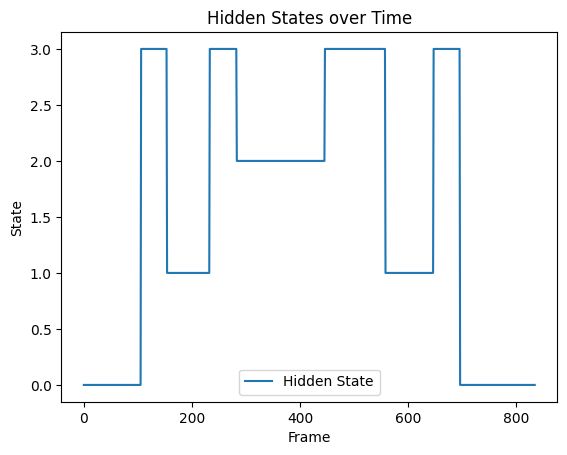

In [6]:
import matplotlib.pyplot as plt

plt.plot(hidden_states, label='Hidden State')
plt.title('Hidden States over Time')
plt.xlabel('Frame')
plt.ylabel('State')
plt.legend()
plt.show()


In [7]:
print("Transition matrix:")
print(model.transmat_)


Transition matrix:
[[0.99589785 0.         0.         0.00410215]
 [0.         0.98817535 0.         0.01182465]
 [0.         0.         0.99389144 0.00610856]
 [0.00388563 0.00777198 0.00388582 0.98445658]]


# Overall

## We shall generalize this for all trials per patient

In [22]:
from hmmlearn.hmm import GaussianHMM
import numpy as np
from tqdm import tqdm


n_states = 6  # Number of hidden states
models = {}

# Loop through each patient
for patient_id in tqdm(range(len(alignment_data_3d)), desc="Fitting HMMs for Patients"):
    
    # Check if the patient has valid trials
    if len(alignment_data_3d[patient_id]) > 0:
        # Combine all trials for this patient into a single dataset
        X_patient = np.concatenate(alignment_data_3d[patient_id], axis=0)

        # Check if X_patient is not empty
        if X_patient.shape[0] > 0:
            # Clean NaNs if necessary (optional)
            X_patient_clean = X_patient[~np.isnan(X_patient).any(axis=1)]
            
            # Fit the HMM model
            model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=1000)
            model.fit(X_patient_clean)
            models[patient_id] = model
        else:
            print(f"Patient {patient_id} has no valid data after cleaning. Skipping this patient.")
    else:
        print(f"Patient {patient_id} has no trials. Skipping this patient.")


Fitting HMMs for Patients:  71%|███████   | 17/24 [02:48<01:08,  9.78s/it]

Patient 17 has no trials. Skipping this patient.


Fitting HMMs for Patients: 100%|██████████| 24/24 [04:05<00:00, 10.22s/it]

Patient 23 has no trials. Skipping this patient.


#### How to interpret the following : 
- Diagonal dominance : look at diagonal elements in each matrix : high values in diagonal means that the system stays in the same state most of the time
- Off-diagonal values : These values indicate transitions between the different states - high off diagonal values might indicate that the patient experiences more vairables states (which might be common for the affected sude)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each patient's model and plot the transition matrices
for patient_id, model in models.items():
    # Transition matrix for the current patient
    transition_matrix = model.transmat_

    # Plot the transition matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(transition_matrix, annot=True, cmap="Blues", fmt=".2f", cbar=True)
    plt.title(f"Transition Matrix for Patient {patient_id}")
    plt.xlabel("Next State")
    plt.ylabel("Current State")
    plt.show()


✅ The phases are distinct and stable.

✅ The model has learned a structured pattern — which is exactly what you want in biomechanical modeling!

✅ The small off-diagonal values in state 5 might suggest some natural variability or overlap in movement phases.

In [12]:
alignment_data_3d[patient_id]

[]

In [9]:
np.any(np.isnan(X_patient))

np.True_

### Now let's check if more states are needed 


- Bayesian Information Criterion (BIC) : Lower BIC means better fit while penalizing model complexity


What is the BIC Score?
The Bayesian Information Criterion (BIC) is a metric used to evaluate how well a statistical model fits the data — while also penalizing for model complexity.

It balances two key factors:

Goodness of fit → How well the model explains the data.

Simplicity → Penalizes adding too many parameters to avoid overfitting.

🔎 Mathematical Formula:
The BIC for an HMM is computed as:

$BIC = -2 log(L) + k \cdot log(N)$

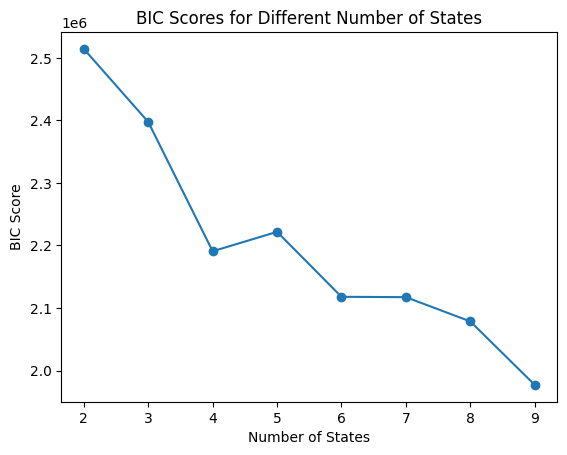

In [19]:
from hmmlearn.hmm import GaussianHMM
import numpy as np

bic_scores = []
n_states_range = range(2, 10)

for n_states in n_states_range:
    model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=1000)
    model.fit(X_patient_clean)
    bic_scores.append(model.bic(X_patient_clean))

import matplotlib.pyplot as plt
plt.plot(n_states_range, bic_scores, marker='o')
plt.title("BIC Scores for Different Number of States")
plt.xlabel("Number of States")
plt.ylabel("BIC Score")
plt.show()


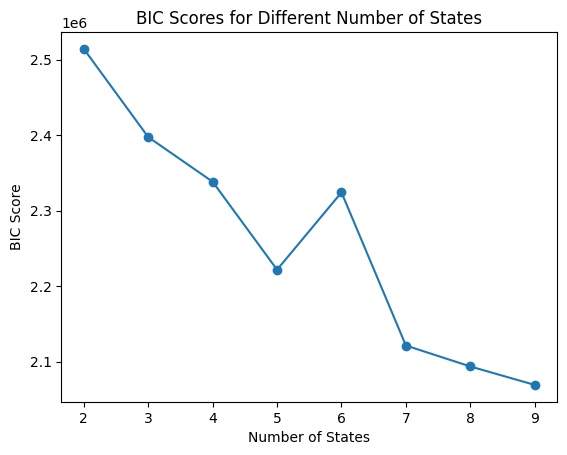

In [24]:
from hmmlearn.hmm import GaussianHMM
import numpy as np

bic_scores = []
n_states_range = range(2, 10)

for n_states in n_states_range:
    model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=1000)
    model.fit(X_patient_clean)
    bic_scores.append(model.bic(X_patient_clean))

import matplotlib.pyplot as plt
plt.plot(n_states_range, bic_scores, marker='o')
plt.title("BIC Scores for Different Number of States")
plt.xlabel("Number of States")
plt.ylabel("BIC Score")
plt.show()


Log likelihood measures how well the model fits the data:

Higher values = Better model fit.

The plot shows that the log likelihood increases up to 8 states, suggesting the model fits better as more states are added.

The drop at 9 states means that adding more states beyond 8 starts to overfit or add unnecessary complexity.

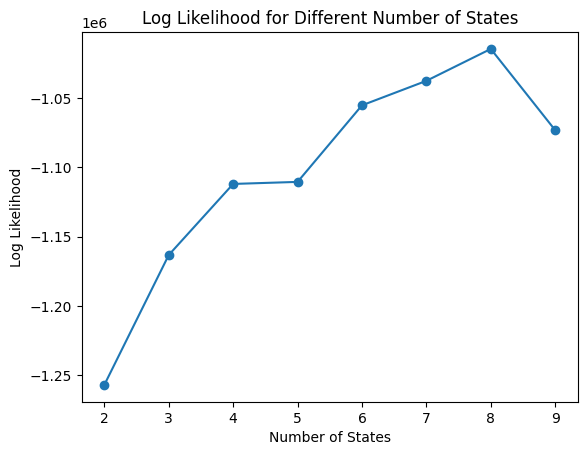

In [20]:
log_likelihoods = []
for n_states in n_states_range:
    model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=1000)
    model.fit(X_patient_clean)
    log_likelihoods.append(model.score(X_patient_clean))

plt.plot(n_states_range, log_likelihoods, marker='o')
plt.title("Log Likelihood for Different Number of States")
plt.xlabel("Number of States")
plt.ylabel("Log Likelihood")
plt.show()


# Let's filter according to affected and unaffected to really visualize the difference

### Affected side : segmentation and phases visualization

In [50]:
from hmmlearn.hmm import GaussianHMM
import numpy as np
from tqdm import tqdm


n_states = 6  # Number of hidden states
models = {}

# Loop through each patient
for patient_id in tqdm(range(len(affected)), desc="Fitting HMMs for Patients"):
    
    # Check if the patient has valid trials
    if len(affected[patient_id]) > 0:
        # Combine all trials for this patient into a single dataset
        X_patient = np.concatenate(affected[patient_id], axis=0)

        # Check if X_patient is not empty
        if X_patient.shape[0] > 0:
            # Clean NaNs if necessary (optional)
            X_patient_clean = X_patient[~np.isnan(X_patient).any(axis=1)]
            
            # Fit the HMM model
            model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=1000)
            model.fit(X_patient_clean)
            models[patient_id] = model
        else:
            print(f"Patient {patient_id} has no valid data after cleaning. Skipping this patient.")
    else:
        print(f"Patient {patient_id} has no trials. Skipping this patient.")


Fitting HMMs for Patients:  71%|███████   | 17/24 [01:41<00:39,  5.70s/it]

Patient 17 has no trials. Skipping this patient.


Fitting HMMs for Patients: 100%|██████████| 24/24 [02:25<00:00,  6.05s/it]

Patient 23 has no trials. Skipping this patient.


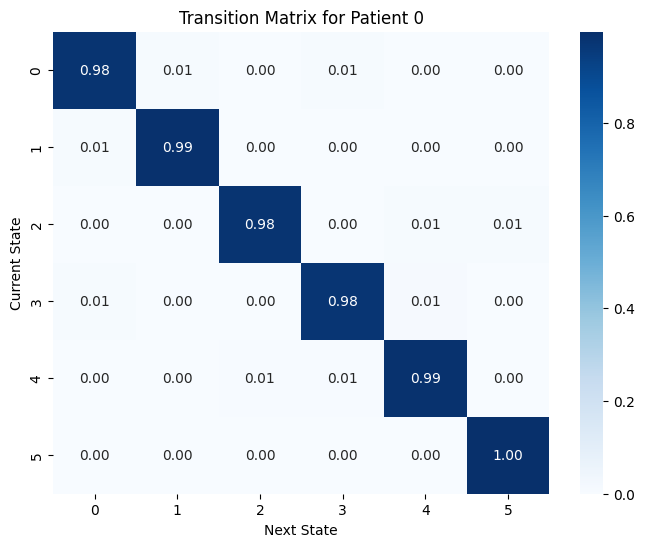

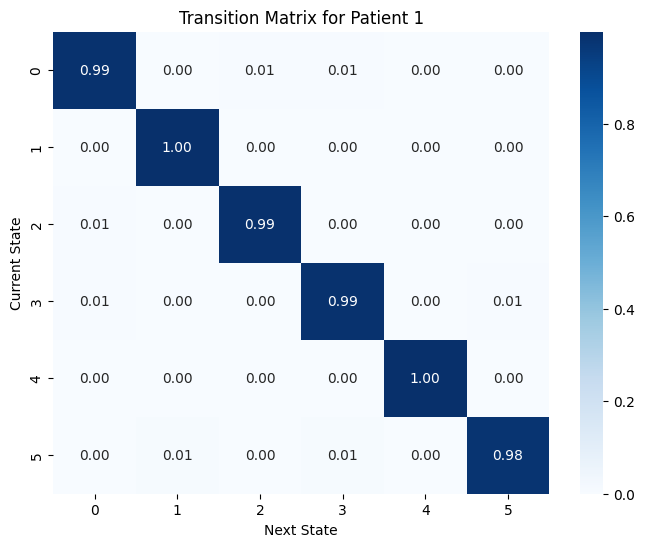

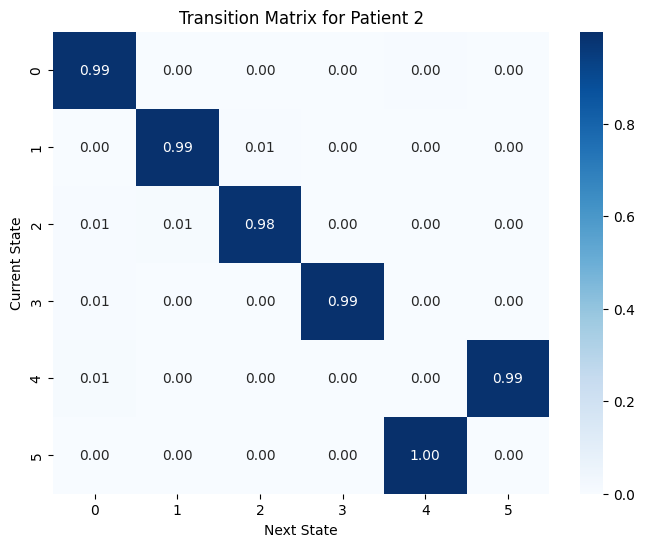

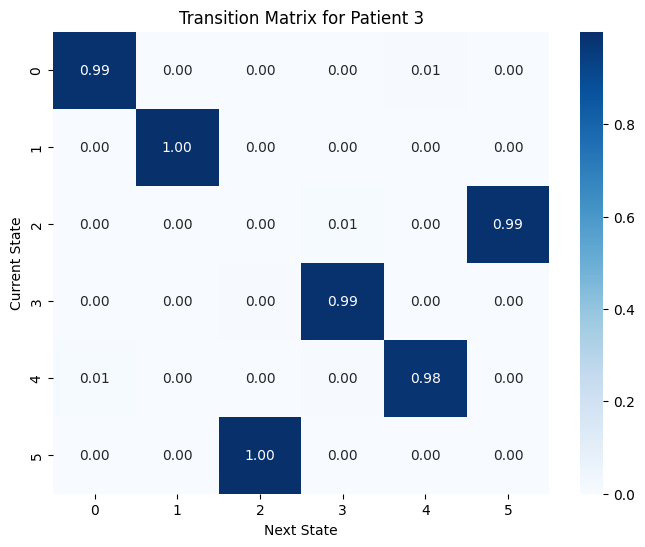

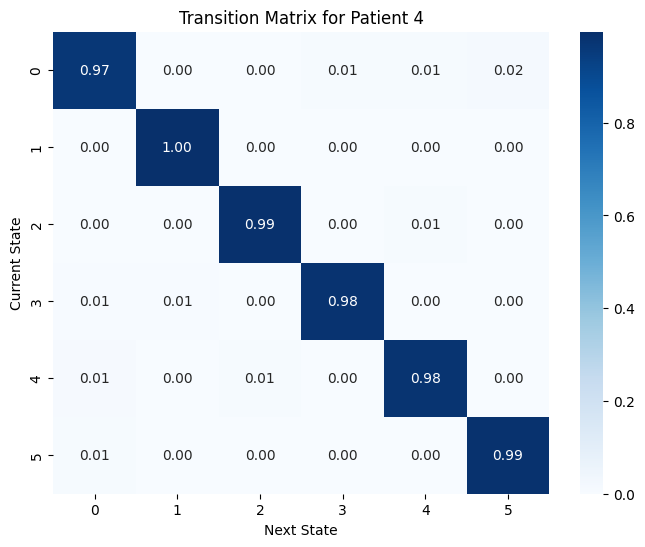

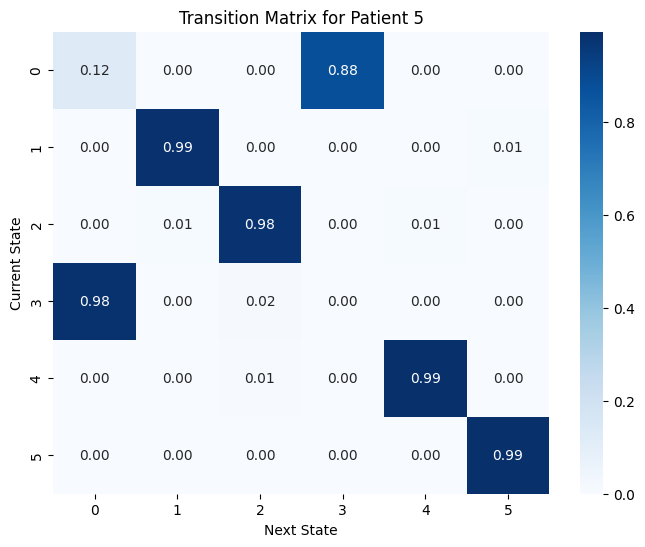

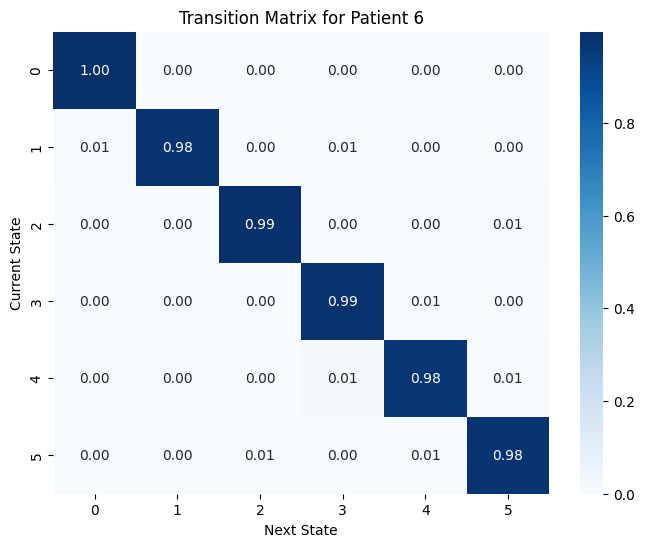

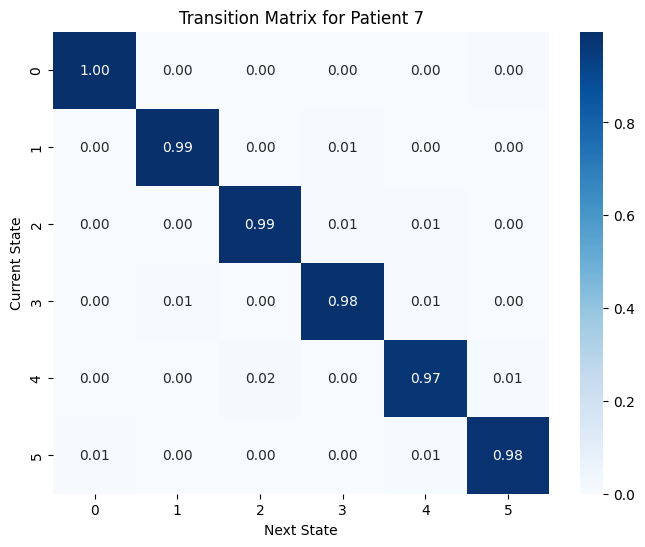

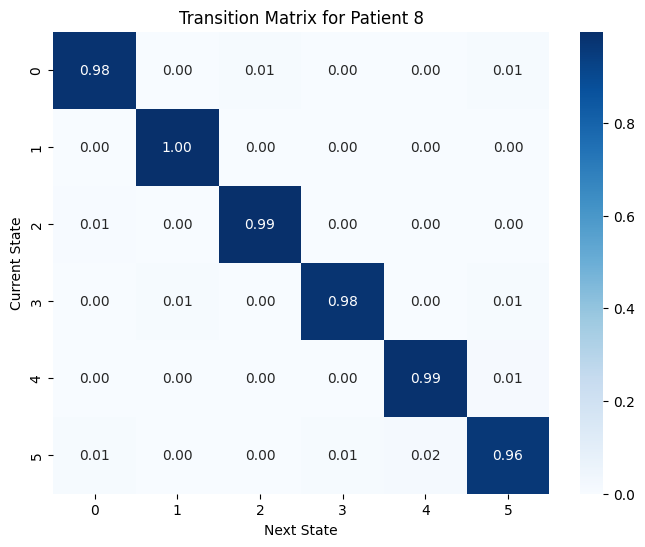

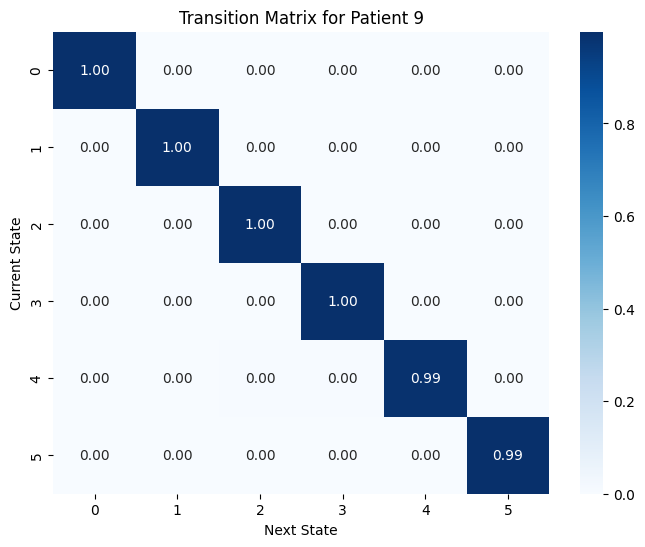

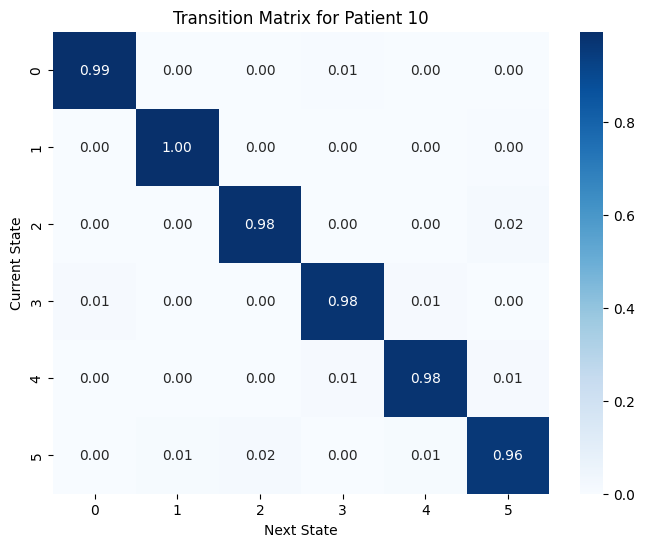

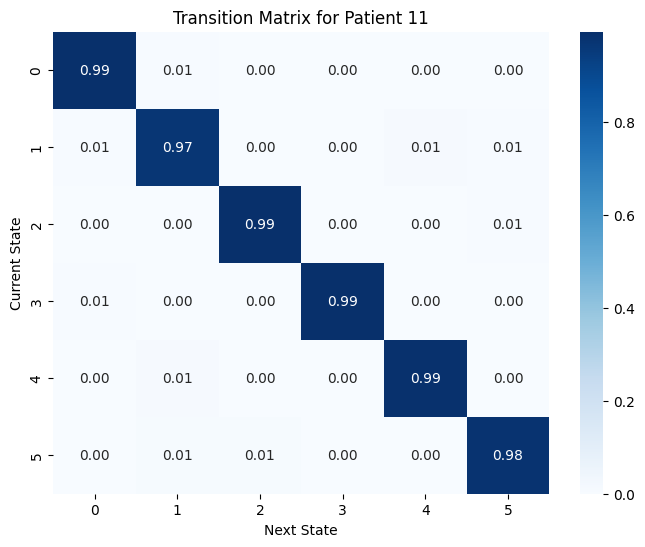

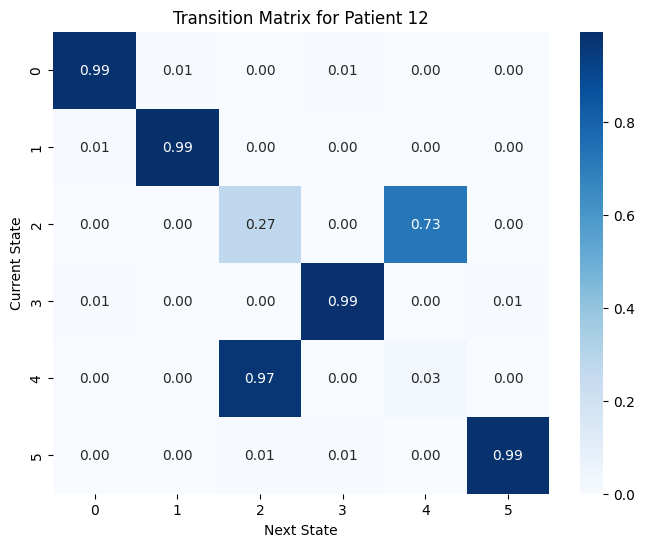

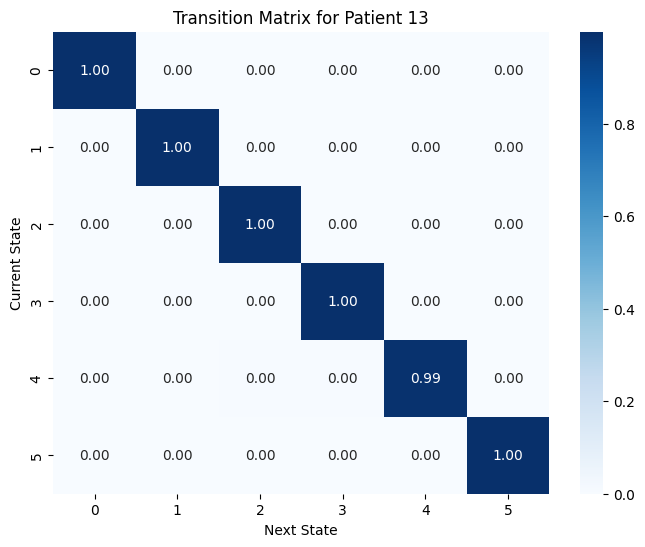

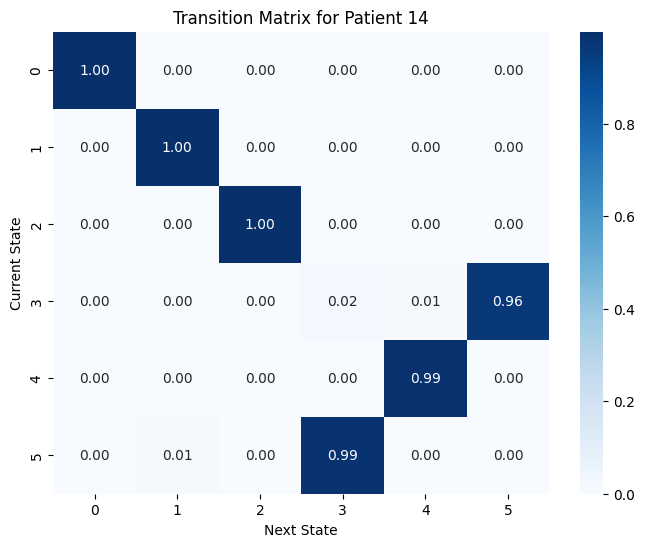

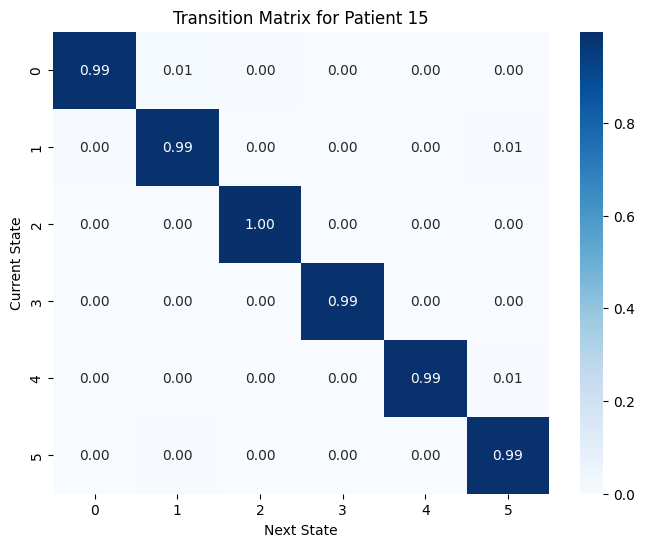

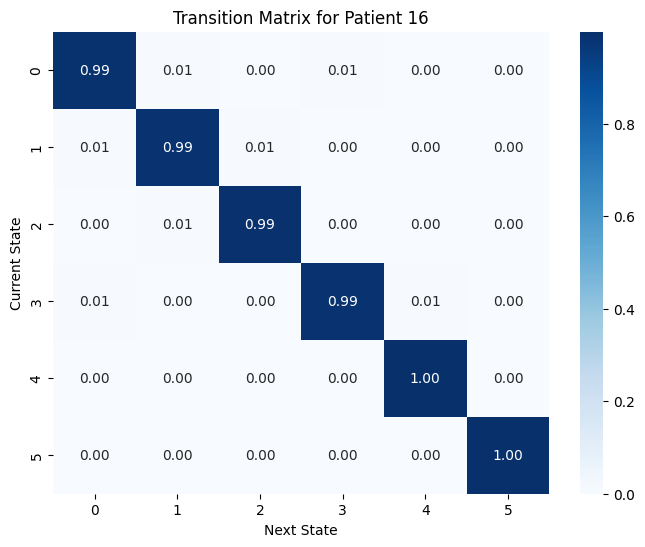

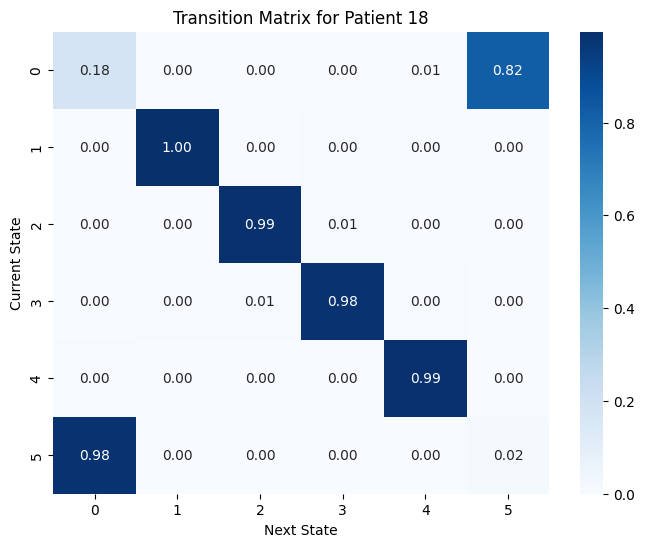

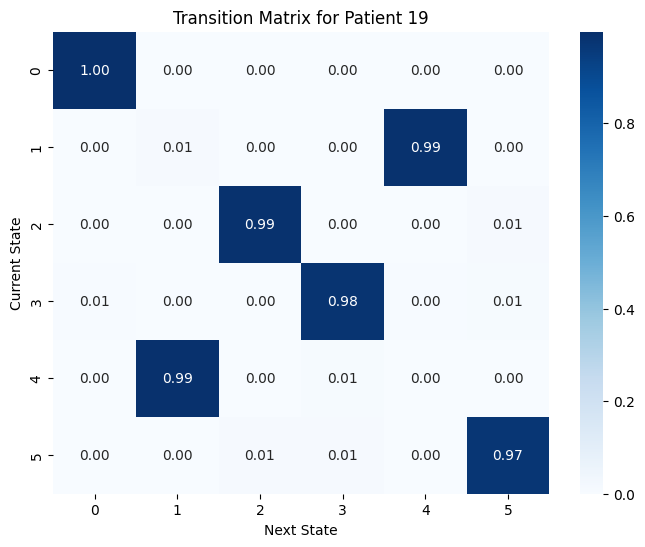

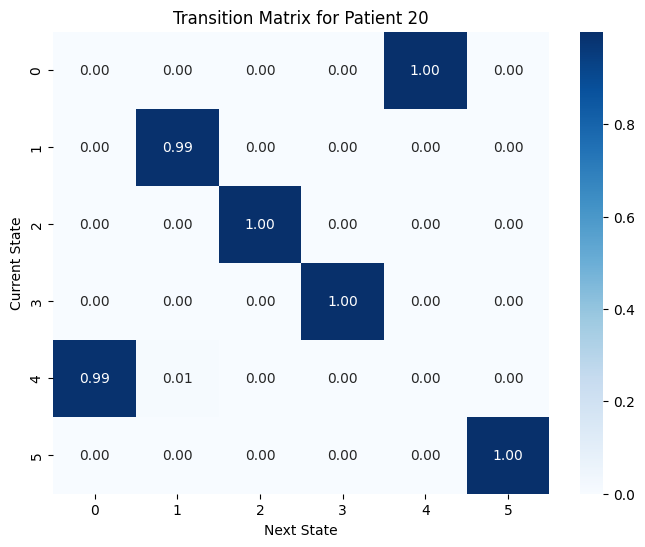

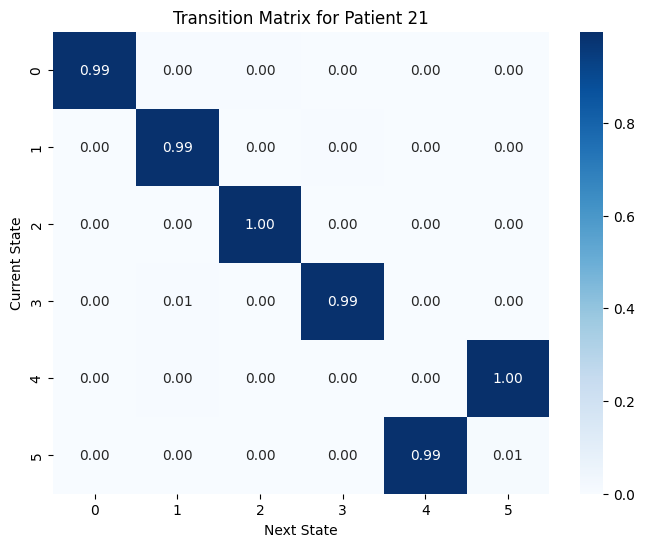

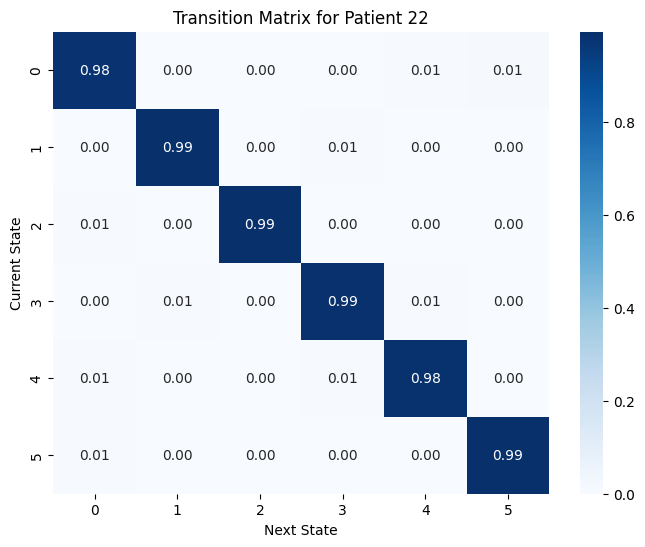

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each patient's model and plot the transition matrices
for patient_id, model in models.items():
    # Transition matrix for the current patient
    transition_matrix = model.transmat_

    # Plot the transition matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(transition_matrix, annot=True, cmap="Blues", fmt=".2f", cbar=True)
    plt.title(f"Transition Matrix for Patient {patient_id}")
    plt.xlabel("Next State")
    plt.ylabel("Current State")
    plt.show()


### Unaffected side 

In [53]:
from hmmlearn.hmm import GaussianHMM
import numpy as np
from tqdm import tqdm


n_states = 6  # Number of hidden states
models = {}

# Loop through each patient
for patient_id in tqdm(range(len(unaffected)), desc="Fitting HMMs for Patients"):
    
    # Check if the patient has valid trials
    if len(unaffected[patient_id]) > 0:
        # Combine all trials for this patient into a single dataset
        X_patient = np.concatenate(unaffected[patient_id], axis=0)

        # Check if X_patient is not empty
        if X_patient.shape[0] > 0:
            # Clean NaNs if necessary (optional)
            X_patient_clean = X_patient[~np.isnan(X_patient).any(axis=1)]
            
            # Fit the HMM model
            model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=1000)
            model.fit(X_patient_clean)
            models[patient_id] = model
        else:
            print(f"Patient {patient_id} has no valid data after cleaning. Skipping this patient.")
    else:
        print(f"Patient {patient_id} has no trials. Skipping this patient.")


Fitting HMMs for Patients:  71%|███████   | 17/24 [01:44<01:09,  9.91s/it]

Patient 17 has no trials. Skipping this patient.


Fitting HMMs for Patients: 100%|██████████| 24/24 [02:42<00:00,  6.76s/it]

Patient 23 has no trials. Skipping this patient.


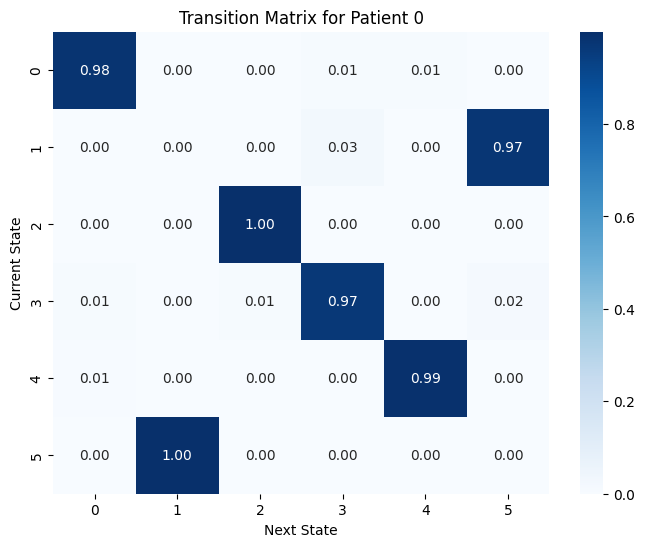

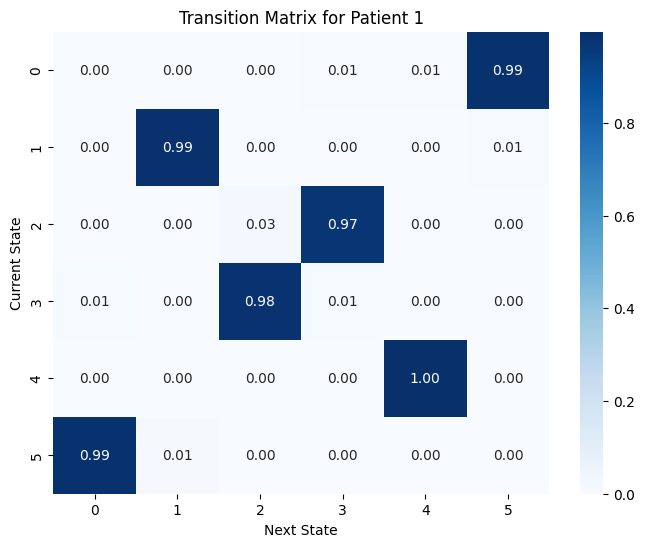

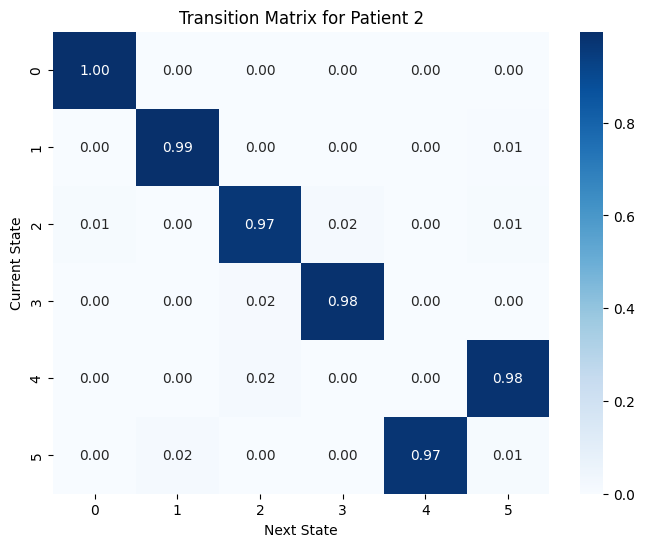

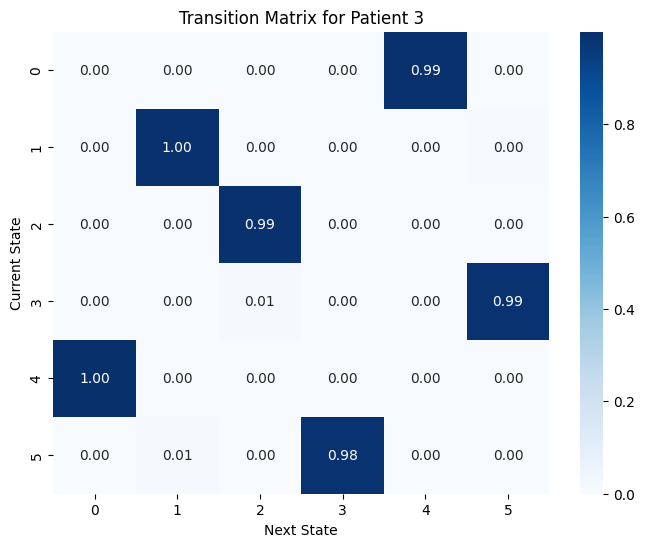

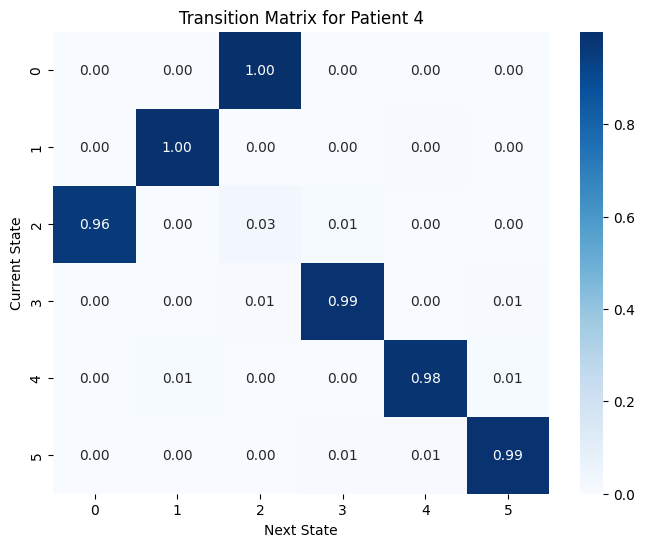

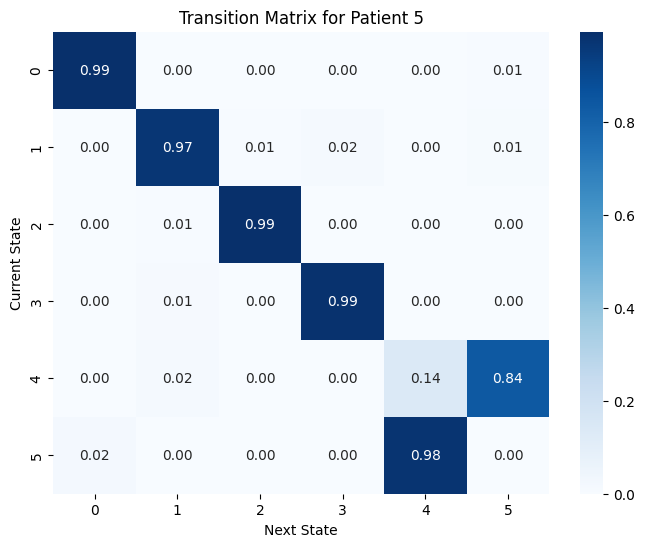

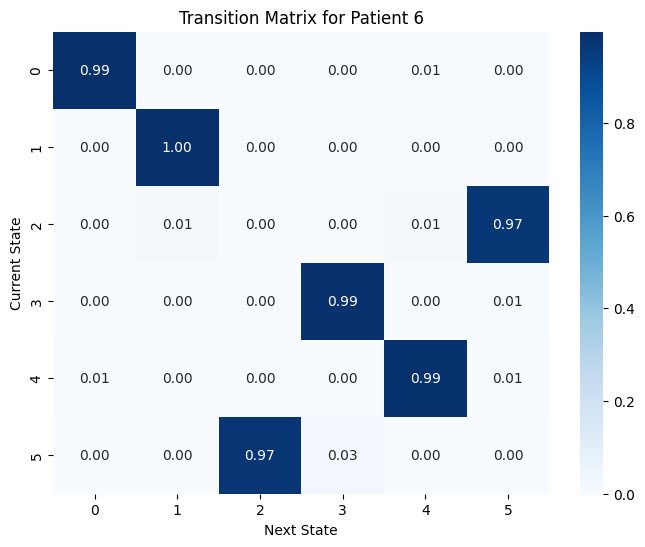

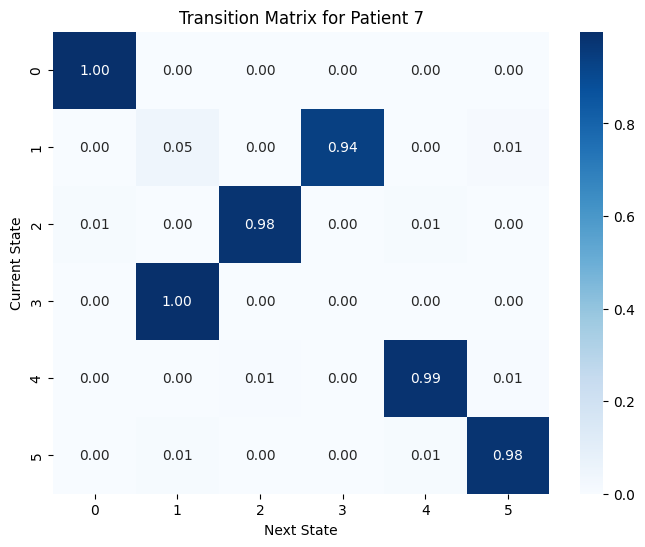

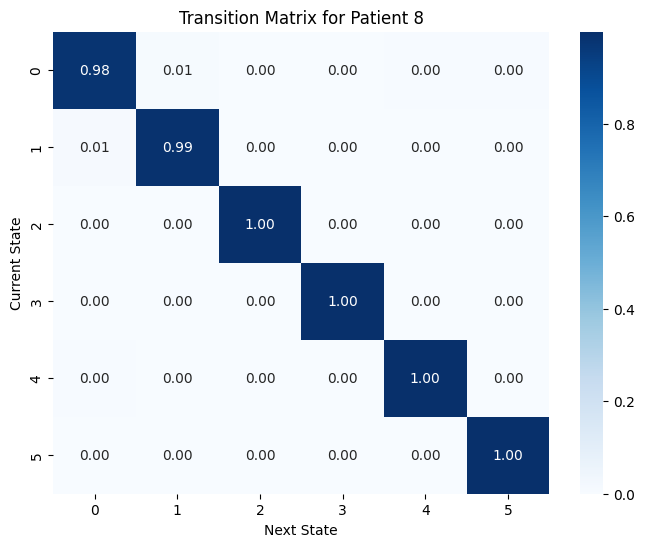

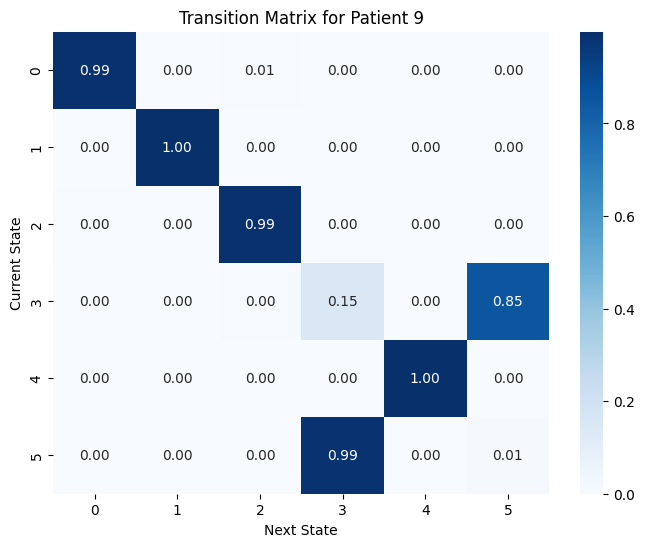

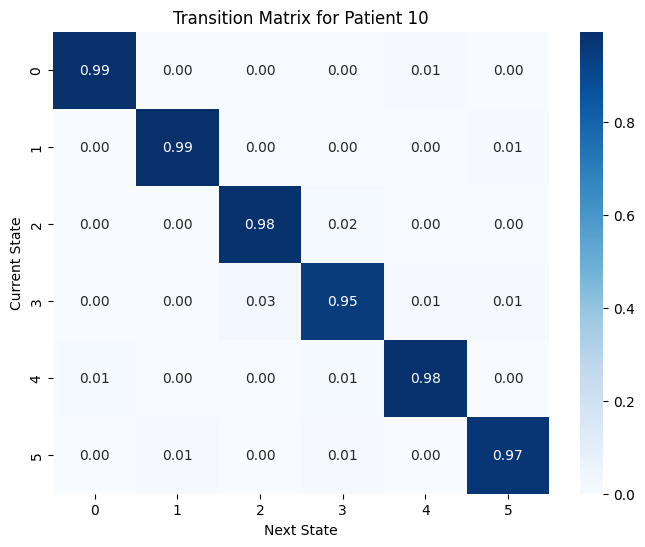

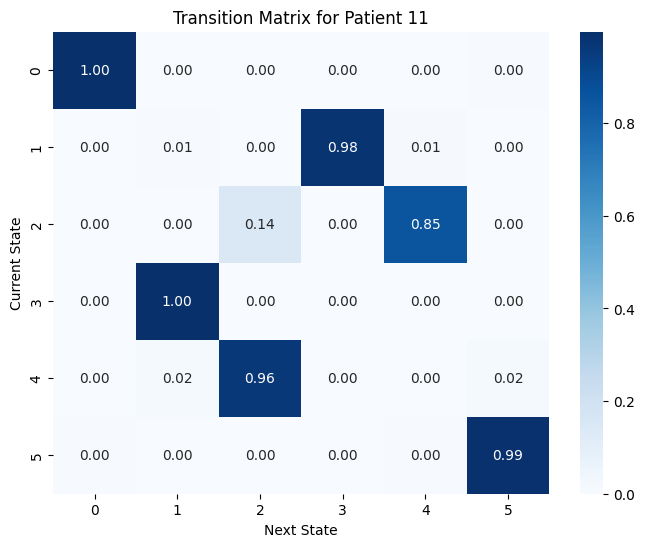

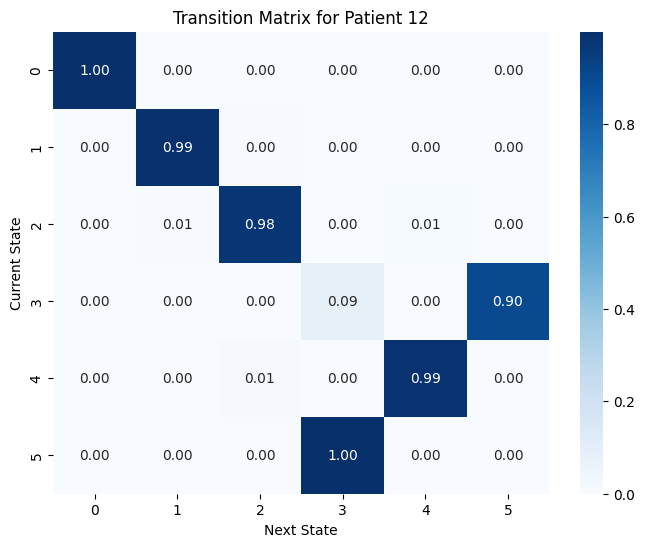

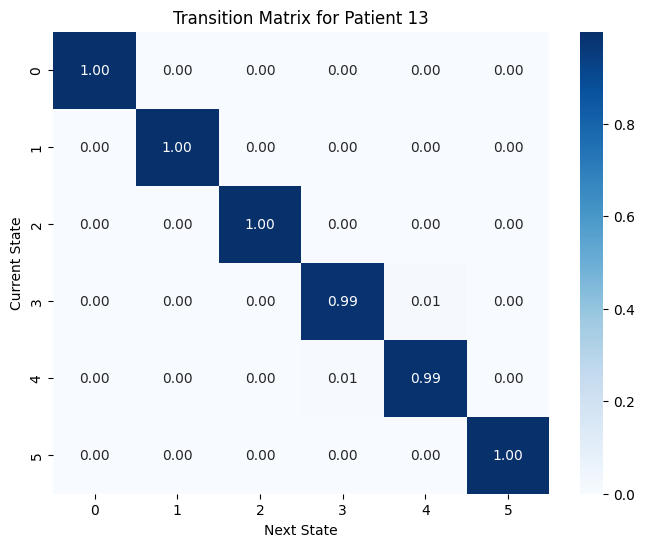

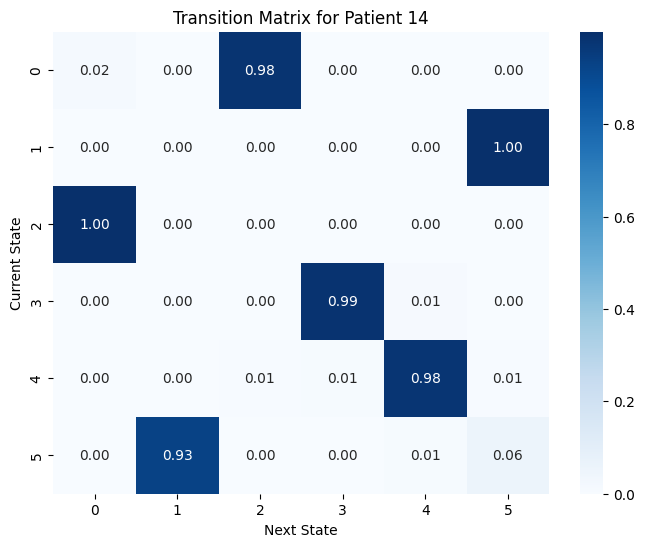

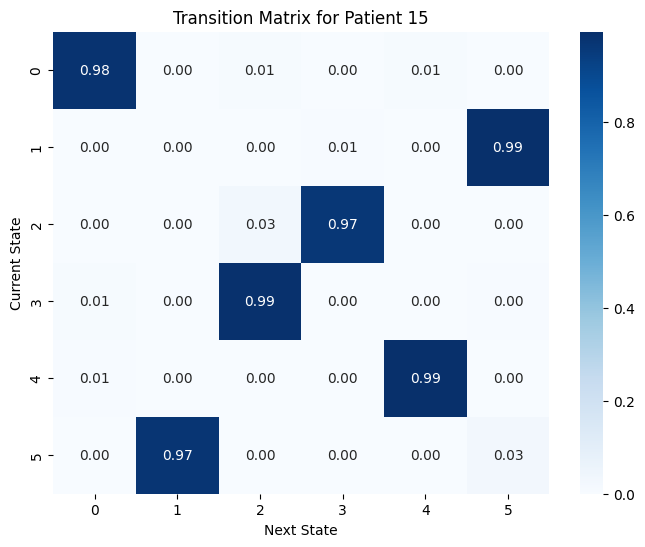

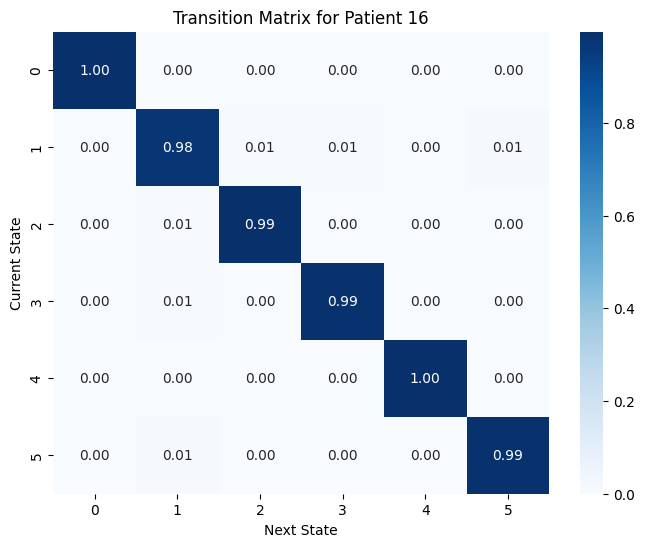

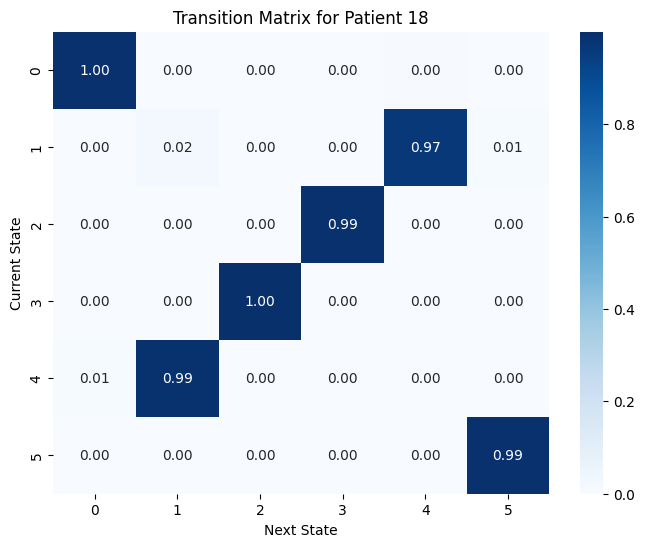

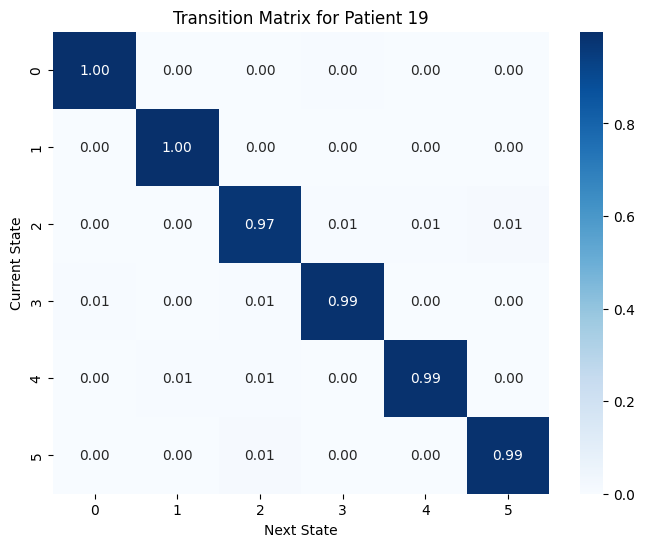

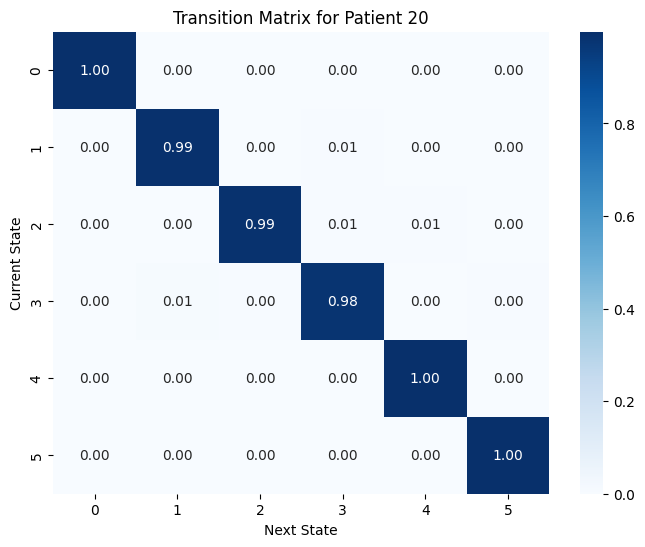

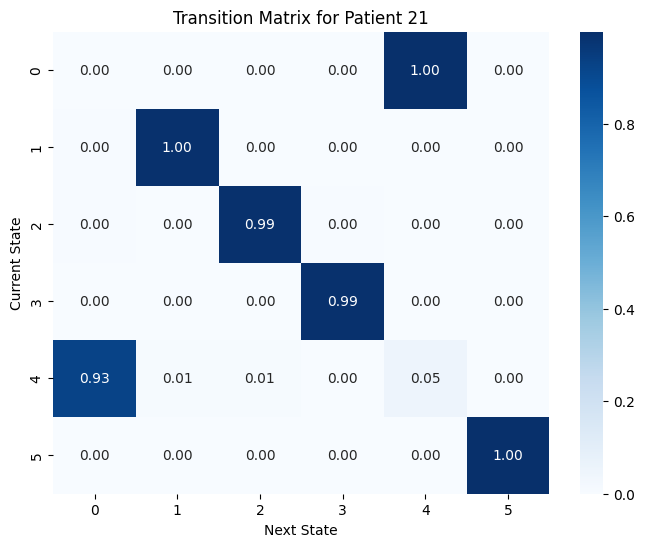

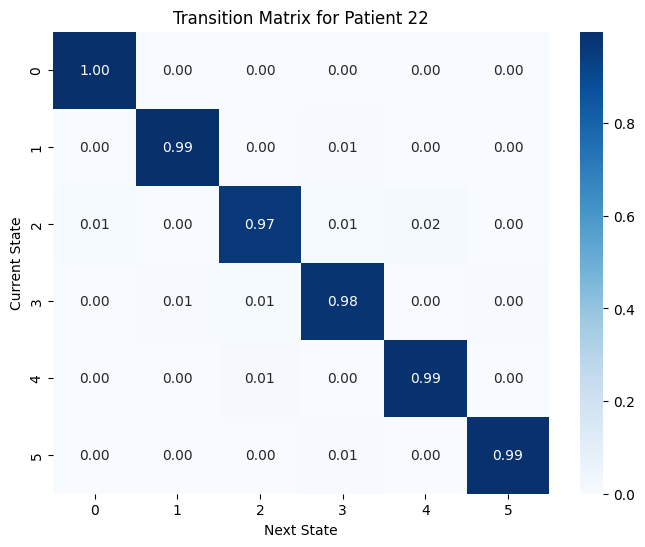

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each patient's model and plot the transition matrices
for patient_id, model in models.items():
    # Transition matrix for the current patient
    transition_matrix = model.transmat_

    # Plot the transition matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(transition_matrix, annot=True, cmap="Blues", fmt=".2f", cbar=True)
    plt.title(f"Transition Matrix for Patient {patient_id}")
    plt.xlabel("Next State")
    plt.ylabel("Current State")
    plt.show()
